# <center>Homework 102

## Task 1

да се имплементира widd & deep архитектура за housing dataset-a. wide частта да получава GPS координатите и да генерира примерно 10 feature-a.

да се сравнят резултатите:

    със и без синтетични feature-и
    с различен брой скрити слоеве
    с тези на синтетичните feature-ит от учебника


In [53]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np

In [56]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

np.random.seed(42)
shufle_inxs = np.random.permutation(len(X))

X, y = X.iloc[shufle_inxs], y.iloc[shufle_inxs]


X_train_full, X_test = X.iloc[:18_000], X.iloc[18_000:]
y_train_full, y_test = y.iloc[:18_000], y.iloc[18_000:]


X_train, X_val = X_train_full.iloc[:16_000], X_train_full.iloc[16_000:] 
y_train, y_val = y_train_full.iloc[:16_000], y_train_full.iloc[16_000:] 

In [57]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [58]:
X_train_wide, X_train_deep = X_train.iloc[:, -2:].to_numpy(), X_train.iloc[:, :-2].to_numpy()
X_val_wide, X_val_deep     = X_val.iloc[:, -2:].to_numpy()  , X_val.iloc[:, :-2].to_numpy() 
X_test_wide, X_test_deep   = X_test.iloc[:, -2:].to_numpy() , X_test.iloc[:, :-2].to_numpy() 

### без синтетични feature-и

In [12]:
wide_inp = tf.keras.layers.Input(name='wide', shape=[2])
deep_inp = tf.keras.layers.Input(name='deep', shape=[6])

norm_wide = tf.keras.layers.Normalization(name='wide_norm')
norm_deep = tf.keras.layers.Normalization(name='deep_norm')

norm_wide.adapt(X_train_wide)
norm_deep.adapt(X_train_deep)

norm_wide = norm_wide(wide_inp)
norm_deep = norm_deep(deep_inp)

hd1 = tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal')(norm_deep)
hd2 = tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal')(hd1)
hd3 = tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal')(hd2)

concat = tf.keras.layers.Concatenate()([norm_wide, hd3])
output = tf.keras.layers.Dense(1)(concat)

model1 = tf.keras.Model(inputs=[wide_inp, deep_inp], outputs=[output])

optimizer = tf.keras.optimizers.Adam()
model1.compile(optimizer=optimizer, loss='mse', metrics=['RootMeanSquaredError'])

model1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ deep (InputLayer)   │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_norm           │ (None, 6)         │         13 │ deep[0][0]        │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 300)       │      2,100 │ deep_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide (InputLayer)   │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 200)       │     60,200 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_norm           │ (None, 2)         │          5 │ wide[0][0]        │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 100)       │     20,100 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 102)       │          0 │ wide_norm[0][0],  │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │        103 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 82,521 (322.36 KB)

 Trainable params: 82,503 (322.28 KB)

 Non-trainable params: 18 (80.00 B)

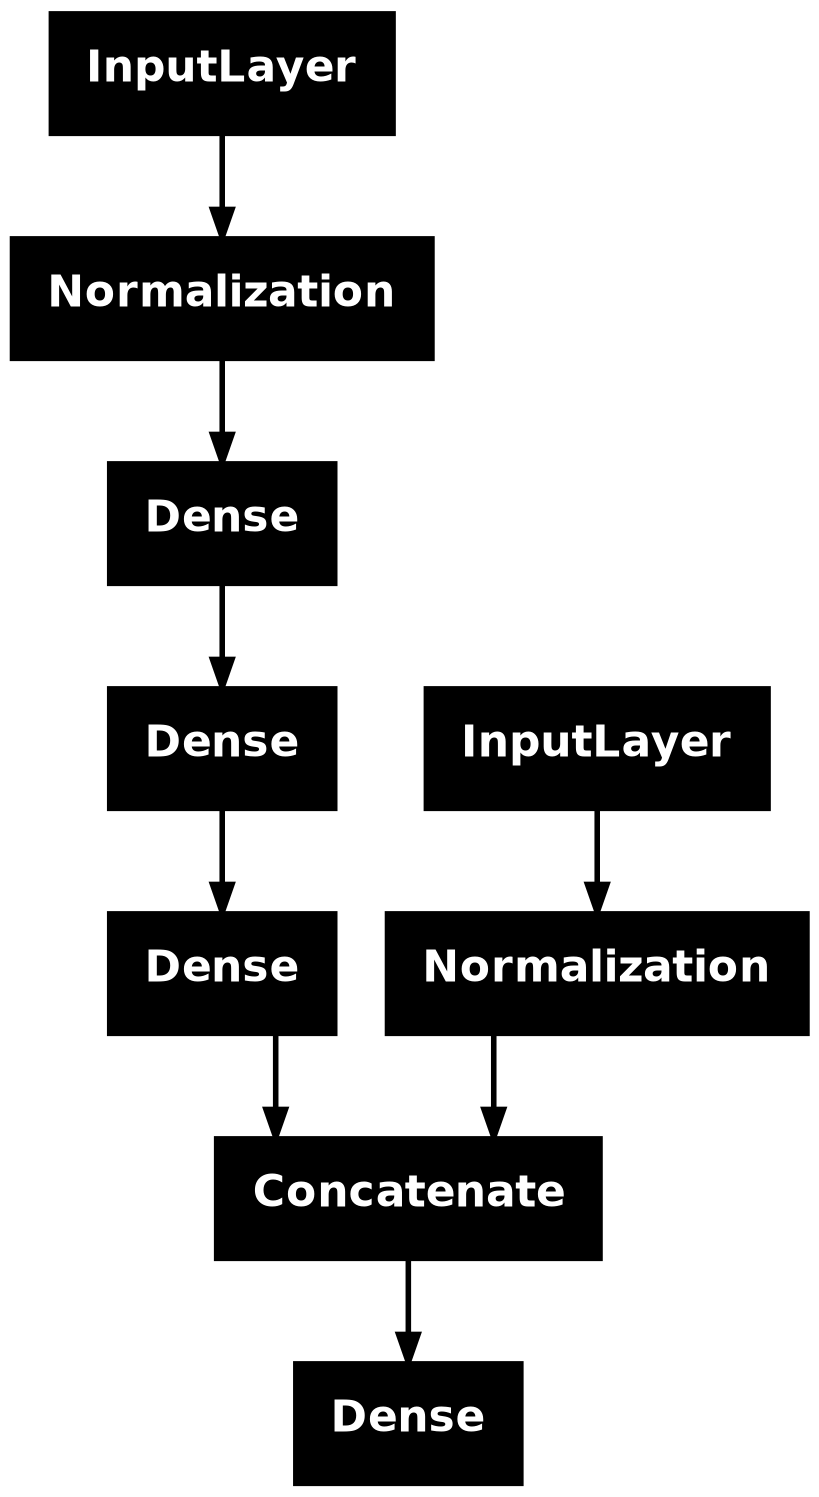

In [13]:
tf.keras.utils.plot_model(model1)

In [14]:
hist1 = model1.fit({'wide': X_train_wide, 'deep':X_train_deep}, y_train, 
           epochs=30,
           validation_data=({'wide': X_val_wide, 'deep':X_val_deep}, y_val)
           )

Epoch 1/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - RootMeanSquaredError: 1.0841 - loss: 1.1752 - val_RootMeanSquaredError: 0.7114 - val_loss: 0.5061
Epoch 2/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 1.2471 - loss: 1.5552 - val_RootMeanSquaredError: 0.6923 - val_loss: 0.4793
Epoch 3/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.7418 - loss: 0.5502 - val_RootMeanSquaredError: 0.6854 - val_loss: 0.4698
Epoch 4/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.6478 - loss: 0.4196 - val_RootMeanSquaredError: 0.7346 - val_loss: 0.5396
Epoch 5/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.6572 - loss: 0.4320 - val_RootMeanSquaredError: 0.6600 - val_loss: 0.4355
Epoch 6/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.9411 - loss: 0.8856 - val_RootMeanSquaredError: 0.6457 - val_loss: 0.4170
Epoch 7/30
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.6203 - los

In [15]:
model1.evaluate({'wide': X_test_wide, 'deep': X_test_deep}, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - RootMeanSquaredError: 0.5921 - loss: 0.3506


[0.350610613822937, 0.592123806476593]

### със синтетични feature-и

In [61]:
X_synthetic = X.iloc[:, -2:].copy()
X_synthetic['Lat*Lon'] = X_synthetic['Latitude'] * X_synthetic['Longitude']
X_synthetic['Lat**2'] = X_synthetic['Latitude'] ** 2
X_synthetic['Lon**2'] = X_synthetic['Longitude'] ** 2

from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

kmeans = KMeans(10, n_init=3, random_state=42)
distances = kmeans.fit_transform(X.iloc[:, -2:])

X_synthetic = np.concatenate([X_synthetic, distances], axis=1)

In [62]:
X_synthetic

array([[ 3.60600000e+01, -1.19010000e+02, -4.29150060e+03, ...,
         3.65449995e+00,  2.63084888e+00,  3.15028924e+00],
       [ 3.51400000e+01, -1.19460000e+02, -4.19782440e+03, ...,
         4.19875341e+00,  3.06074265e+00,  3.24336277e+00],
       [ 3.78000000e+01, -1.22440000e+02, -4.62823200e+03, ...,
         1.61442650e+00,  1.44750820e+00,  7.55982034e-01],
       ...,
       [ 3.40300000e+01, -1.18380000e+02, -4.02847140e+03, ...,
         5.68858093e+00,  4.57806213e+00,  4.78742989e+00],
       [ 3.75800000e+01, -1.21960000e+02, -4.58325680e+03, ...,
         1.50549570e+00,  9.89878659e-01,  3.39568224e-01],
       [ 3.77700000e+01, -1.22420000e+02, -4.62380340e+03, ...,
         1.62132904e+00,  1.42760191e+00,  7.20362986e-01]],
      shape=(20640, 15))

In [63]:
X_synthetic = X_synthetic[shufle_inxs]

X_train_full_syn, X_test_syn = X_synthetic[:18_000], X_synthetic[18_000:] 
X_train_syn, X_val_syn = X_train_full_syn[:16_000], X_train_full_syn[16_000:]

In [64]:
wide_inp = tf.keras.layers.Input(name='wide', shape=[15])
deep_inp = tf.keras.layers.Input(name='deep', shape=[6])

norm_wide = tf.keras.layers.Normalization(name='wide_norm')
norm_deep = tf.keras.layers.Normalization(name='deep_norm')

norm_wide.adapt(X_train_syn)
norm_deep.adapt(X_train_deep)

norm_wide = norm_wide(wide_inp)
norm_deep = norm_deep(deep_inp)

hd1 = tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal')(norm_deep)
hd2 = tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal')(hd1)
hd3 = tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal')(hd2)

concat = tf.keras.layers.Concatenate()([norm_wide, hd3])
output = tf.keras.layers.Dense(1)(concat)

model2 = tf.keras.Model(inputs=[wide_inp, deep_inp], outputs=[output])

optimizer = tf.keras.optimizers.Adam()
model2.compile(optimizer=optimizer, loss='mse', metrics=['RootMeanSquaredError'])

model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ deep (InputLayer)   │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_norm           │ (None, 6)         │         13 │ deep[0][0]        │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 300)       │      2,100 │ deep_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide (InputLayer)   │ (None, 15)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 200)       │     60,200 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_norm           │ (None, 15)        │         31 │ wide[0][0]        │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 100)       │     20,100 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 115)       │          0 │ wide_norm[0][0],  │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │        116 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 82,560 (322.51 KB)

 Trainable params: 82,516 (322.33 KB)

 Non-trainable params: 44 (184.00 B)

In [65]:
hist1 = model2.fit({'wide': X_train_syn, 'deep':X_train_deep}, y_train, 
           epochs=30,
           validation_data=({'wide': X_val_syn, 'deep':X_val_deep}, y_val)
           )

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - RootMeanSquaredError: 1.0559 - loss: 1.1149 - val_RootMeanSquaredError: 0.7866 - val_loss: 0.6188
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 1.7416 - loss: 3.0330 - val_RootMeanSquaredError: 0.7156 - val_loss: 0.5121
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - RootMeanSquaredError: 0.8068 - loss: 0.6510 - val_RootMeanSquaredError: 0.6888 - val_loss: 0.4744
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.7760 - loss: 0.6022 - val_RootMeanSquaredError: 0.6803 - val_loss: 0.4628
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.9024 - loss: 0.8143 - val_RootMeanSquaredError: 0.6636 - val_loss: 0.4404
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6769 - loss: 0.4582 - val_RootMeanSquaredError: 0.6665 - val_loss: 0.4442
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.6556 - los

In [66]:
model2.evaluate({'wide': X_test_syn, 'deep': X_test_deep}, y_test)

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - RootMeanSquaredError: 0.6515 - loss: 0.4245


[0.42449405789375305, 0.6515321135520935]

### с различен брой скрити слоеве

In [68]:
from sklearn.preprocessing import StandardScaler

deep_scaler = StandardScaler().fit(X_train_deep)
wide_scaler = StandardScaler().fit(X_train_syn)

X_train_full_deep = deep_scaler.transform(X_train_full.iloc[:, :-2].to_numpy())
X_train_deep = deep_scaler.transform(X_train_deep)
X_val_deep = deep_scaler.transform(X_val_deep)
X_test_deep = deep_scaler.transform(X_test_deep)

X_train_full_syn = wide_scaler.transform(X_train_full_syn)
X_train_syn = wide_scaler.transform(X_train_syn)
X_val_syn = wide_scaler.transform(X_val_syn)
X_test_syn = wide_scaler.transform(X_test_syn)

In [39]:
def build_model(hp):
    wide_inp = tf.keras.layers.Input(name='wide', shape=[15])
    deep_inp = tf.keras.layers.Input(name='deep', shape=[6])

    n_hidden = hp.Int("n_hidden", min_value=1, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256, default=50)
    initializer = hp.Choice('initializer', values=['he_normal', 'he_uniform'])

    last_layer = deep_inp
    for _ in range(n_hidden):
        last_layer = tf.keras.layers.Dense(n_neurons, activation='relu', kernel_initializer=initializer)(last_layer)

    concat = tf.keras.layers.Concatenate()([wide_inp, last_layer])
    output = tf.keras.layers.Dense(1)(concat)
    model = tf.keras.Model(inputs=[wide_inp, deep_inp], outputs=[output])

    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='mse', metrics=['RootMeanSquaredError'])
    return model

In [69]:
import keras_tuner as kt

random_search_tuner = kt.RandomSearch(
                build_model, objective="val_RootMeanSquaredError", max_trials=5, overwrite=True,
                directory="my_dir", project_name="housing_syn", seed=42
                )

random_search_tuner.search({'wide': X_train_syn, 'deep': X_train_deep}, y_train, 
                           epochs=10, 
                           validation_data=({'wide': X_val_syn, 'deep': X_val_deep}, y_val))

Trial 5 Complete [00h 00m 26s]
val_RootMeanSquaredError: 1.0453379154205322

Best val_RootMeanSquaredError So Far: 0.6691974401473999
Total elapsed time: 00h 02m 14s


In [71]:
random_search_tuner.get_best_hyperparameters(1)[0].values

{'n_hidden': 8,
 'n_neurons': 164,
 'initializer': 'he_uniform',
 'learning_rate': 0.00015159319577885927,
 'optimizer': 'adam'}

In [72]:
best_model = random_search_tuner.get_best_models(1)[0]

his3 = best_model.fit({'wide': X_train_full_syn, 'deep': X_train_full_deep}, y_train_full,
               epochs=20)

Epoch 1/20


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - RootMeanSquaredError: 0.6552 - loss: 0.4293
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.6517 - loss: 0.4247
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - RootMeanSquaredError: 0.6482 - loss: 0.4202
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.6488 - loss: 0.4209
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.6389 - loss: 0.4082
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - RootMeanSquaredError: 0.6434 - loss: 0.4140
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.6515 - loss: 0.4244
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - RootMeanSquaredError: 0.6430 - loss: 0.4134
Epoch 9/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - RootMeanSquaredError: 0.6256 - loss: 0.3913
Epoch 10/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - RootMeanSquaredError: 0.6225 - loss: 0.3875
Epoch 11/20
563/563 ━━━━━━━━━━

In [73]:
best_model.evaluate({'wide': X_test_syn, 'deep': X_test_deep}, y_test)

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.6732 - loss: 0.4532


[0.4531881511211395, 0.6731925010681152]

In [74]:
60 / 12

5.0

## Task 5

да се тества обученеито на моделе fashion MNIST

    с ралични видове инициализация
    с различен брой layer-и
    с различен брой неврони във layer-ите

да се намери оптималната конмбинация от хиперпараметри с оригиналините класове RandomSearch и Hyperband

In [75]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [76]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [77]:
def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256, default=50)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    activation = hp.Choice("activation", values=["relu", "tanh"])
    initializer_inx = hp.Choice('initializer', values=[0, 1])

    if activation == 'relu':
        initializer = ['he_normal', 'he_uniform'][initializer_inx]
    else:
        initializer = ['glorot_normal', 'glorot_uniform'][initializer_inx]

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation, kernel_initializer=initializer))
    
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

In [79]:
random_search_tuner = kt.RandomSearch(
                build_model, objective="val_accuracy", max_trials=5, overwrite=True,
                directory="my_dir", project_name="fashion_mnist", seed=42
                )

random_search_tuner.search(X_train, y_train, 
                           epochs=10, 
                           validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 00m 54s]
val_accuracy: 0.8708000183105469

Best val_accuracy So Far: 0.8758000135421753
Total elapsed time: 00h 05m 25s


In [80]:
random_search_tuner.get_best_hyperparameters(1)[0].values

{'n_hidden': 3,
 'n_neurons': 135,
 'learning_rate': 0.007177664122743156,
 'optimizer': 'sgd',
 'activation': 'relu',
 'initializer': 0}

In [81]:
best_model = random_search_tuner.get_best_models(1)[0]
best_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8678 - loss: 0.3700


[0.3699578642845154, 0.8677999973297119]

In [83]:
tuner = kt.Hyperband(build_model, objective="val_accuracy", max_epochs=10,
    factor=3, directory="my_dir", project_name="fashion_mnist_Hyperband")

callbacks = [tf.keras.callbacks.EarlyStopping(patience=3)]
tuner.search(X_train, y_train, validation_data=(X_valid, y_valid), callbacks=callbacks)

Trial 26 Complete [00h 02m 10s]
val_accuracy: 0.8619999885559082

Best val_accuracy So Far: 0.8838000297546387
Total elapsed time: 00h 24m 22s


In [85]:
tuner.get_best_hyperparameters(1)[0].values

{'n_hidden': 2,
 'n_neurons': 229,
 'learning_rate': 0.0021978128955561574,
 'optimizer': 'adam',
 'activation': 'relu',
 'initializer': 0,
 'tuner/epochs': 10,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0}

In [86]:
best_model = tuner.get_best_models(1)[0]
best_model.evaluate(X_test, y_test)

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8763 - loss: 0.3719


[0.37193965911865234, 0.8762999773025513]

## Questions

2. Draw an ANN using the original artificial neurons (like the ones in Figure 10-3)
that computes A ⊕ B (where ⊕ represents the XOR operation). Hint: A ⊕ B = (A ∧ ¬ B) ∨ (¬ A ∧ B).

![XOR ANN](XOR.png)

3. Why is it generally preferable to use a logistic regression classifier rather than a
classic perceptron (i.e., a single layer of threshold logic units trained using the
perceptron training algorithm)? How can you tweak a perceptron to make it
equivalent to a logistic regression classifier?

*3. Защо обикновено е за предпочитане да се използва класификатор на логистична регресия, а не a
класически перцептрон (т.е. един слой от прагови логически единици, обучени с помощта на
алгоритъм за обучение на перцептрон)? Как можете да настроите перцептрон, за да го направите
еквивалентен на класификатор на логистична регресия?*


- logistic regression използва loss func, SGD при обучение докато perceptron обновява теглата само
когато има грешка и няма градиент
- perceptron не може да конвергира когато класовете не са линейно разделими 
- logistic regression има predict_proba
- logistic regression използва регуларизация

За да се направи perceptron == logistic regression:
- активационната функция -> sigmoid
- лосс -> cross-entropy
- оптимизатор -> SGD

4. Why was the sigmoid activation function a key ingredient in training the first MLPs?

*4. Защо сигмоидната активираща функция е била ключова съставка в обучението на първите MLP?*

- това позволява на модела да започне да улавя не линейно раделими данни 
- гладка и диференцируема
- това позволява изчисляване на градиенти и използване на backpropagation

5. Name three popular activation functions. Can you draw them?

*5. Назовете три популярни функции за активиране. Можете ли да ги нарисувате?*

- relu
- tanh
- sigmoid

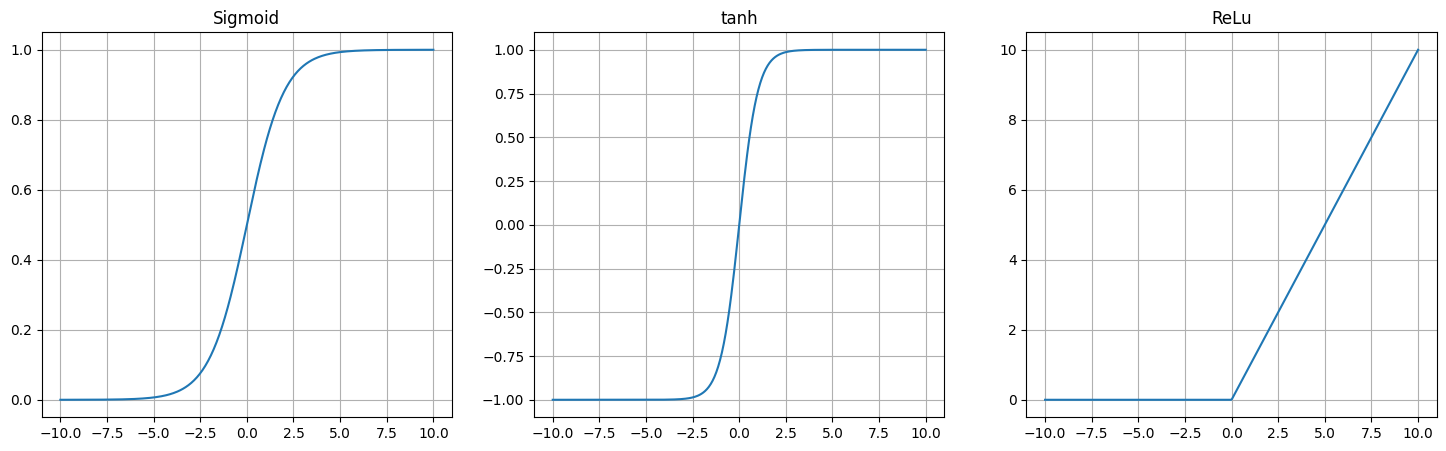

In [95]:
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sigmoid = lambda z: 1 / (1 + np.exp(-z))
tanh = lambda z: 2 * sigmoid(2 * z) - 1
def relu(z):
    res = np.zeros_like(z)
    mask = z > 0
    res[mask] = z[mask]
    return res

ax[0].set_title('Sigmoid')
ax[0].plot(x, sigmoid(x), label='sigmoid')
ax[0].grid()

ax[1].set_title('tanh')
ax[1].plot(x, tanh(x), label='tanh')
ax[1].grid()

ax[2].set_title('ReLu')
ax[2].plot(x, relu(x), label='relu')
ax[2].grid()

6. Suppose you have an MLP composed of one input layer with 10 passthrough
neurons, followed by one hidden layer with 50 artificial neurons, and finally
one output layer with 3 artificial neurons. All artificial neurons use the ReLU
activation function.
a. What is the shape of the input matrix X?
b. What are the shapes of the hidden layer’s weight matrix Wh and bias vector bh?
c. What are the shapes of the output layer’s weight matrix Wo and bias vector bo?
d. What is the shape of the network’s output matrix Y?
e. Write the equation that computes the network’s output matrix Y as a function
of X, Wh, bh, Wo, and bo.

*6. Да предположим, че имате MLP, съставен от един входен слой с 10 преминавания
неврони, последван от един скрит слой с 50 изкуствени неврони и накрая
един изходен слой с 3 изкуствени неврона. Всички изкуствени неврони използват ReLU
функция за активиране.
а. Каква е формата на входната матрица X?
b. Какви са формите на матрицата за тегло на скрития слой Wh и вектора на отклонение bh?
c. Какви са формите на тегловната матрица Wo на изходния слой и вектора на отклонение bo?
d. Каква е формата на изходната матрица Y на мрежата?
д. Напишете уравнението, което изчислява изходната матрица Y на мрежата като функция
на X, Wh, bh, Wo и bo.*

- a. (n_samples, 10)
- b. Wh: (50, 10) bh: (50, 1)
- c. Wo: (3, 50) bo: (3, 1)
- d. (n_samples, 3)
- e. Y = relu(relu(X_inp @ Wh.t + bh) @ Wo + bo)

7. How many neurons do you need in the output layer if you want to classify email
into spam or ham? What activation function should you use in the output layer?
If instead you want to tackle MNIST, how many neurons do you need in the
output layer, and which activation function should you use? What about for
getting your network to predict housing prices, as in Chapter 2?

*7. Колко неврони са ви необходими в изходния слой, ако искате да класифицирате имейл
в спам или хам? Каква функция за активиране трябва да използвате в изходния слой?
Ако вместо това искате да се заемете с MNIST, колко неврони са ви необходими в
изходен слой и коя функция за активиране трябва да използвате? Какво ще кажете за
да накарате вашата мрежа да предвижда цените на жилищата, както в глава 2?*

- spam or ham -> neurons: 1, activation: sigmoid
- MNIST -> neurons: 10, activation: softmax
- housing prices -> neurons: 1, activation: None

8. What is backpropagation and how does it work? What is the difference between
backpropagation and reverse-mode autodiff?

*8. Какво е обратно разпространение и как работи? Каква е разликата между
обратно разпространение и автоматична разлика в обратен режим?*

- backpropagation работи като за всеки minin batch прави първо forward pass изчислява лоса и градиента на изходния слой след това прави backward pass и верижно разпространява този грешката по скритите слоеве и така им изчислява градиентите на теглата след това ги обновява според learning rate

- backpropagation е специализиран reverse-mode autodiff алгоритъм за обучение на невронни мрежи
- reverse-mode autodiff по-общ метод за автоматично изчисляване на градиенти

9. Can you list all the hyperparameters you can tweak in a basic MLP? If the MLP
overfits the training data, how could you tweak these hyperparameters to try to
solve the problem?

*9. Можете ли да изброите всички хиперпараметри, които можете да променяте в основен MLP? Ако MLP
превишава данните за обучение, как бихте могли да промените тези хиперпараметри, за да опитате
разреши проблема?*

- брой скрити слоеве, брой неврони, активационна функция, първоначална инициализация на тегла, оптимизатор, лърнинг рейт, лосс функция, брой епохи за обучение, размер на бачовете

- намаляване на сложността на модела - по малко слоеве и неврони 
- по малко епохи за трениране
- повече на данни
- може би промяна на лърнинг рейт и размер на бачовете